#Introduction

### The Influence of Missing Data on Model Performance

In this experiment, the effect of missing data on machine learning model performance is investigated.

The Logistic Regression model is trained on datasets containing different amounts of missing values. The objective is to determine how increasing the proportion of missing data influences the predictive performance of the model.

All missing values are handled using median imputation to simulate a common preprocessing technique used in real-world machine learning projects.

##Import Libraries

The required libraries are imported for data processing, model training, and evaluation

In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score)

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

## Load Dataset

The Titanic dataset is loaded for the experiment.

In [68]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Selecting Features

The same features used in the previous experiments are selected to ensure a fair comparison.

The selected features are:

- Passenger Class
- Sex
- Age
- Fare

The target variable is Survived.

In [69]:
df = df[['Survived','Pclass','Sex','Age','Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


## Checking Missing Values

The number of missing values is examined before data preprocessing.

In [70]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
Fare,0


## Creating the Experiment Function

To avoid repeating the same code several times, a function is created.

The function automatically:

- creates a copy of the dataset;
- introduces a selected percentage of missing values;
- fills missing values using the median;
- encodes categorical variables;
- splits the dataset;
- trains a Logistic Regression model;
- calculates the evaluation metrics.

This approach ensures that every experiment is performed under identical conditions.

In [71]:
def evaluate_missing_data(df, missing_fraction):

    # Create a copy
    data = df.copy()

    # Add missing values
    if missing_fraction > 0:
        missing_index = data.sample(frac=missing_fraction,random_state=42).index

        data.loc[missing_index, "Age"] = np.nan

    # Fill missing values
    data["Age"] = data["Age"].fillna(data["Age"].median())

    # One-hot encoding
    data = pd.get_dummies( data,columns=["Sex"],drop_first=True)

    # Features and target
    X = data.drop("Survived", axis=1)
    y = data["Survived"]

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

    # Model
    model = LogisticRegression(max_iter=1000,random_state=42)

    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()


    return {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "True Negative": tn,
    "False Positive": fp,
    "False Negative": fn,
    "True Positive": tp}

## Running Experiments

The experiment is performed with different levels of missing data.

Four datasets are evaluated:

- Original dataset (0% missing data)
- Dataset with 10% missing values
- Dataset with 20% missing values
- Dataset with 30% missing values

This allows analyzing how increasing the amount of missing data affects machine learning performance.

In [72]:
results = []

missing_levels = [0, 0.1, 0.2, 0.3]

for level in missing_levels:

  result = evaluate_missing_data(df, level)

  result["Missing Data"] = f"{int(level*100)}%"

  results.append(result)

## Results Comparison

The results from all experiments are combined into a single table to compare the influence of different levels of missing data.

In [74]:
comparison = pd.DataFrame(results)

comparison = comparison[[ "Missing Data", "Accuracy", "Precision","Recall","F1-score","True Negative","False Positive","False Negative","True Positive"]]

comparison = comparison.round(3)

comparison

,Missing Data,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,0%,0.804,0.783,0.730,0.755,90,15,20,54
1,10%,0.788,0.757,0.716,0.736,88,17,21,53
2,20%,0.777,0.743,0.703,0.722,87,18,22,52
3,30%,0.777,0.743,0.703,0.722,87,18,22,52


## Analysis of Results

The experiment demonstrates that increasing the amount of missing data negatively affects the performance of the Logistic Regression model.

The model trained on the original dataset without additional missing values achieved the best results, with an Accuracy of 0.804 and an F1-score of 0.755.

When 10% of missing data was introduced, the model performance decreased. Accuracy dropped from 0.804 to 0.788, while the F1-score decreased from 0.755 to 0.736.

With 20% missing data, the performance decreased further, reaching an Accuracy of 0.777 and an F1-score of 0.722. Increasing missing data from 20% to 30% did not significantly change the results, which indicates that the model reached a similar performance level after a certain amount of data degradation.

The confusion matrix analysis also shows the impact of missing data on predictions. As missing values increased, True Negative predictions decreased from 90 to 87, while False Positive and False Negative errors increased. This indicates that incomplete data makes it more difficult for the model to correctly identify patterns in the dataset.

Overall, the results confirm that data quality plays an important role in machine learning performance. Higher levels of missing information reduce the amount of useful information available for training and lead to less accurate predictions.

## Conclusion

In this experiment, the influence of missing data on machine learning performance was investigated using Logistic Regression and the Titanic dataset.

The results showed that increasing the amount of missing data negatively affects model performance. The original dataset achieved the highest evaluation scores, while datasets with larger amounts of missing information produced lower Accuracy, Precision, Recall, and F1-score values.

The confusion matrix analysis confirmed that data degradation increased the number of incorrect predictions and reduced the model's ability to classify passenger outcomes correctly.

This experiment demonstrates that data quality is a critical factor in machine learning. Proper data preprocessing and handling of missing values are necessary to build reliable and accurate predictive models.

## Accuracy Change Depending on Missing Data

The graph below shows how increasing the amount of missing data affects model accuracy.

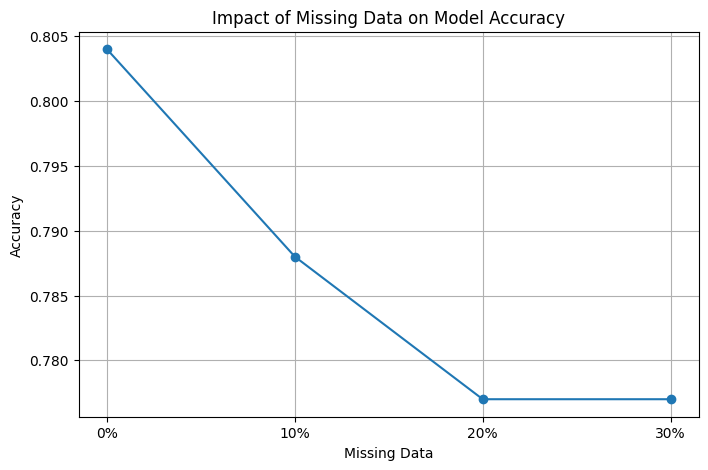

In [87]:
plt.figure(figsize=(8,5))

plt.plot( comparison["Missing Data"],comparison["Accuracy"],marker="o")

plt.xlabel("Missing Data")
plt.ylabel("Accuracy")
plt.title("Impact of Missing Data on Model Accuracy")

plt.grid(True)

plt.show()